In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from scipy.stats import norm
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import jax.numpy as jnp
from jax import random


# Time domain models

## Estructura de autorregresiones 

Consideremos una serie de tiempo con cantidades espaciadas igualitariamente $y_t$ para $t =1,2,...$ que surge del siguiente modelo:

$$y_t= \sum_{j=1}^{p}\phi_j y_{t-j}+\epsilon_t$$

Donde asumimos que $\epsilon_t \sim N(0, v)$, es decir, se distribuye normalmente con media cero y varianza $v$ y, por lo tanto, independiente.

### Estacionariedad de un proceso AR

Una característica deseable de los procesos AR es la estabilidad, es decir, que sean estacionarios y por tanto tengan media y varianza constantes en el tiempo, independientes de $t$.

Un proceso $AR(p)$ es estacionario si y solo si las raíces de su polinomio característico $\Phi(u) = 1 - \sum_{j=1}^{p}\phi_ju^j$ caen fuera del círculo unitario, es decir, si son mayores a uno en módulo.

Para ilustrar de dónde viene esta condición, consideremos el caso más simple, un $AR(1)$:

$$y_t = \phi y_{t-1} + \epsilon_t$$

Usando el operador de rezago $L$ (donde $Ly_t = y_{t-1}$), el proceso se escribe como $(1-\phi L)y_t = \epsilon_t$, de donde el polinomio característico es:

$$\Phi(u) = 1 - \phi u$$

cuya raíz es $u = 1/\phi$. La condición $|u|>1$ equivale entonces a $|\phi|<1$: la restricción sobre el polinomio característico es también una restricción sobre el propio coeficiente autorregresivo.

Para verificar que esta condición es, en efecto, la que garantiza media y varianza constantes, partamos de un punto arbitrario $y_0$ y sustituyamos recursivamente hacia atrás:

$$
\begin{aligned}
y_t &= \phi \big[ \phi y_{t-2} + \epsilon_{t-1}\big] + \epsilon_t \\
&= \phi \bigg[ \phi \big[\phi y_{t-3} + \epsilon_{t-2}\big] + \epsilon_{t-1}\bigg] + \epsilon_t \\
&\ \ \vdots\\
&= \phi^{t}y_0 + \sum_{j=0}^{t-1}\phi^{j}\epsilon_{t-j}
\end{aligned}
$$

Esta expresión escribe a $y_t$ enteramente en términos de la condición inicial $y_0$ y de los choques $\epsilon_{t-j}$, lo que nos permite calcular su media y varianza.

Tomando esperanza (y asumiendo $\text{E}[\epsilon_t]=0$ para todo $t$) y varianza (asumiendo $\epsilon_t$ ruido blanco con varianza $v$, y por tanto no correlacionado entre periodos):

$$
\begin{aligned}
\text{E}[y_t] &= \phi^{t}y_0 \\
\text{Var}[y_t] &= \sum_{j=0}^{t-1}\text{Var}[\phi^{j}\epsilon_{t-j}] \\
&= v\sum_{j=0}^{t-1}\phi^{2j}\\
&= v\frac{1 - \phi^{2t}}{1 - \phi^{2}}
\end{aligned}
$$

Ambas expresiones dependen explícitamente de $t$, así que en general el proceso **no** es estacionario para $t$ finita. Solo cuando $|\phi|<1$ el término $\phi^t$ (y por tanto $\phi^{2t}$) decae a cero conforme $t\to\infty$, y la media y varianza convergen a los valores constantes $0$ y $v/(1-\phi^2)$. Si $|\phi|\geq 1$, estos términos no desaparecen o incluso divergen, y el proceso nunca estabiliza su media y varianza.

Generalizando, consideremos ahora un modelo $AR(p)$ cuyo polinomio característico es $\Phi(u) = 1 - \sum_{j=1}^{p}\phi_ju^j$:

Para encontrar las raices usamos el teorema fundamental del álgebra para reescribir el polinomio de la siguiente forma:

$$
\begin{aligned}
\Phi(u) &= c(u-u_1)\dots(u-u_p) \\
&= c\big[(-u_1(1-u/u_1))\dots(-u_p(1-u/u_p))\big] \\
&= c(1-u/u_1)\dots(1-u/u_p)
\end{aligned}
$$

donde $c$ absorbe las constantes $u_i$. Entonces el inverso del polinomio característico es
$$
\begin{aligned}
\Phi(u)^{-1} &= c^{-1}(1-u/u_1)^{-1}\dots(1-u/u_p)^{-1}
\end{aligned}
$$

Para que cada factor $(1-u/u_i)^{-1}$ converja como serie geométrica en potencias de $u$, se necesita $|u/u_i| < 1$. Como $u$ pasa a representar el operador de rezago $L$ (que desplaza la serie sin escalarla, es decir, "actúa" con módulo 1), la condición de convergencia debe sostenerse en $|u| = 1$, lo cual da $|u_i| > 1$ para cada raíz $u_i$, $i=1,\dots,p$.

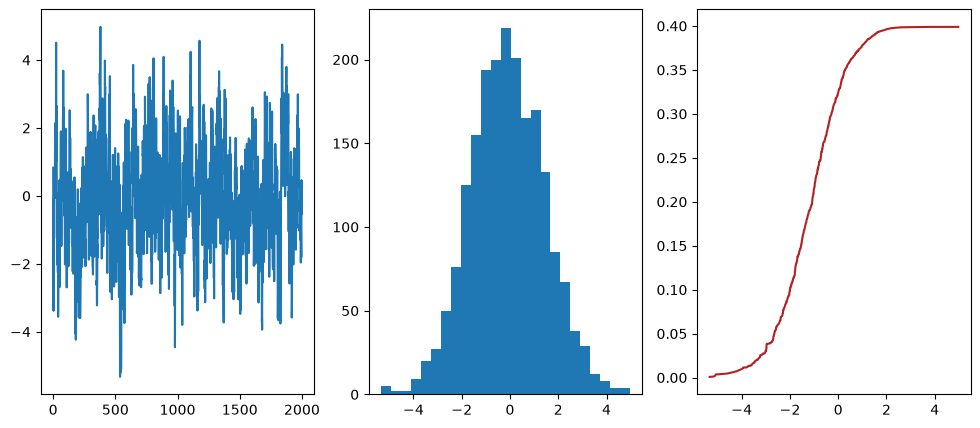

In [3]:
# Modelo AR(2) estacionario
n = 2000
phi = np.array([0.5, 0.3])

y = np.zeros(n)
y[0] = np.random.normal()
y[1] = np.random.normal()



for i in range(2, n):
    y[i] =  np.dot(phi, y[i-2:i][::-1]) + np.random.normal()

# Obtenemos probabilidades con proceso markoviano
sigma2 = 1
phi1, phi2 = phi 
gamma0 = sigma2 * (1 - phi2) / ((1+ phi2) *((1-phi2)**2 - phi1**2))
gamma1 = phi1 * gamma0 / (1 - phi2)

mu = np.array([0,0])
Sigma = np.array([[gamma0, gamma1],
                  [gamma1, gamma0]])

p_init = multivariate_normal(mu, Sigma).pdf(y[:2])

medias = phi1 * y[1:n-1] + phi2 * y[0:n-2]
p_cond = norm(medias, np.sqrt(sigma2)).pdf(y[2:])

# Graficamos
fig, ax = plt.subplots(ncols=3, figsize=(12,5))
ax[0].plot(np.arange(n), y)
ax[1].hist(y, bins=25)
ax[2].plot(np.sort(y[2:]), np.sort(p_cond), color='firebrick')


In [13]:
y_jax = jnp.array(y)

def model(y):
    phi1 = numpyro.sample("phi1", dist.Normal(0,0.5))
    phi2 = numpyro.sample("phi2", dist.Normal(0,0.5))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.))

    medias = phi1 * y[1:-1] + phi2 * y[:-2]
    numpyro.sample("y_obs", dist.Normal(medias,sigma), obs=y[2:])

nuts_kernel = NUTS(model)
mcmc = MCMC(nuts_kernel, num_warmup=500, num_samples=10000)
mcmc.run(random.PRNGKey(0), y = y_jax)


sample: 100%|██████████| 10500/10500 [00:05<00:00, 2033.89it/s, 7 steps of size 4.71e-01. acc. prob=0.94]


In [14]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      phi1      0.52      0.02      0.52      0.48      0.55   4725.44      1.00
      phi2      0.29      0.02      0.29      0.25      0.32   4812.22      1.00
     sigma      1.02      0.02      1.02      0.99      1.04   6731.04      1.00

Number of divergences: 0
